# Import and Helper

In [1]:
import sys
from importlib import reload
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import PatchPoint, PatchSet, plot_patchset


# ============================================================
# Imports / reloading / helper functions
# ============================================================
import sys
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "/mnt/data" not in sys.path:
    sys.path.insert(0, "/mnt/data")

import noninteracting
import interaction
import frg_kernel
import channels
import frg_flow

reload(noninteracting)
reload(interaction)
reload(frg_kernel)
reload(channels)
reload(frg_flow)

from interaction import BareExtendedHubbard
from channels import SZ0ChannelBuilder
from frg_flow import FRGFlowSolverSZ0, BareSZ0VertexFromInteraction, FlowStepRecord
import instability
reload(instability)

from instability import (
    InstabilityConfig,
    diagnose_kernel_collection,
)
from frg_kernel import FlowConfig

def build_sz0_builder_from_solver(solver, *, Landau_F=None):
    if Landau_F is None:
        Landau_F = getattr(solver, "diagnosis_landau_F", False)
    return SZ0ChannelBuilder(
        vertex=solver.current_vertex_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=getattr(solver, "q_merge_tol_red", 5e-2),
        q_key_decimals=getattr(solver, "q_key_decimals", 10),
        Landau_F=Landau_F,
    )


def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)


def sign_aware_channel_score(channel_name, M):
    H = hermitian_part(M)
    evals, _ = np.linalg.eigh(H)
    eval_pos_max = float(np.max(evals))
    eval_neg_min = float(np.min(evals))

    if channel_name.startswith("pp"):
        physical_score = max(eval_pos_max, 0.0)
        chosen_eval = eval_pos_max
        chosen_sign = "positive"
    elif channel_name.startswith("ph"):
        physical_score = max(-eval_neg_min, 0.0)
        chosen_eval = eval_neg_min
        chosen_sign = "negative"
    else:
        raise ValueError(f"Unknown channel name: {channel_name}")

    return {
        "eval_pos_max": eval_pos_max,
        "eval_neg_min": eval_neg_min,
        "physical_score": float(physical_score),
        "chosen_eval": float(chosen_eval),
        "chosen_sign": chosen_sign,
        "herm_resid": float(np.max(np.abs(M - M.conjugate().T))),
    }


def evaluate_selected_Qs(builder, diagnosis_Qs, *, landau_F=False):
    rows = []
    kernel_store = {}
    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=landau_F)
        kernel_store[iq] = {"Q": np.asarray(Q, dtype=float), "kernels": kernel_dict}
        for ch_name, ker in kernel_dict.items():
            info = sign_aware_channel_score(ch_name, ker.matrix)
            rows.append({
                "channel": ch_name,
                "Q_index": int(iq),
                "Q": np.asarray(Q, dtype=float),
                "Qx": float(Q[0]),
                "Qy": float(Q[1]),
                **info,
            })
    df = pd.DataFrame(rows)
    return df, kernel_store


def fmt_q(q, nd=3):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def plot_signaware_bars(df, *, title):
    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]
    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0]["physical_score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("sign-aware physical score")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


def choose_signaware_eigenpair(channel_name, M):
    H = hermitian_part(M)
    evals, evecs = np.linalg.eigh(H)
    if channel_name.startswith("pp"):
        idx = int(np.argmax(evals))
    elif channel_name.startswith("ph"):
        idx = int(np.argmin(evals))
    else:
        raise ValueError(f"Unknown channel_name={channel_name}")
    vec = np.asarray(evecs[:, idx], dtype=complex)
    val = float(evals[idx].real)
    vec = vec / np.linalg.norm(vec)
    return val, vec


def leading_row_from_df(df):
    if len(df) == 0:
        raise ValueError("Empty diagnosis dataframe.")
    return df.sort_values("physical_score", ascending=False).iloc[0]


def print_step_summary(rec):
    payload = rec.diagnosis_payload
    if "sign_aware" not in payload:
        print(
            f"step={rec.step_index:4d} | T={rec.temperature:.6f} | "
            f"rhs_norm={rec.rhs_norm:.3e} | no sign-aware payload"
        )
        return

    sa = payload["sign_aware"]
    lead_ch = sa["leading_channel"]
    lead_qi = sa["leading_Q_index"]
    lead_q = np.asarray(sa["leading_Q"], dtype=float)
    lead_score = sa["leading_score"]

    # per-channel scores at the leading Q
    q_entry = None
    for item in sa["per_Q"]:
        if int(item["Q_index"]) == int(lead_qi):
            q_entry = item
            break

    if q_entry is None:
        print(
            f"step={rec.step_index:4d} | T={rec.temperature:.6f} | "
            f"rhs_norm={rec.rhs_norm:.3e} | leader={lead_ch} @ {fmt_q(lead_q)} score={lead_score:.3e}"
        )
        return

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]
    score_str = ", ".join(
        f"{ch}={float(q_entry['channels'][ch]['physical_score']):.3e}" for ch in channels_order
    )
    print(
        f"step={rec.step_index:4d} | T={rec.temperature:.6f} | rhs_norm={rec.rhs_norm:.3e} | "
        f"leader={lead_ch} @ Q{lead_qi}:{fmt_q(lead_q)} score={lead_score:.3e} | {score_str}"
    )


def manual_run_flow_live(solver, snapshot_steps=None):
    if snapshot_steps is None:
        snapshot_steps = set()
    else:
        snapshot_steps = set(int(x) for x in snapshot_steps)

    temps = solver.temperature_path
    snapshots = {}

    rec0 = FlowStepRecord(
        step_index=0,
        temperature=float(temps[0]),
        dT=0.0,
        channel_norm=solver.state.channel_norm(),
        rhs_norm=0.0,
        accepted_substeps=0,
        max_rel_update=0.0,
        diagnosis_payload=solver.diagnose_current_state(),
    )
    rec0.instability, rec0.instability_reason = solver.check_instability(rec0)
    solver.history = [rec0]
    solver.instability_record = rec0 if rec0.instability else None

    if 0 in snapshot_steps:
        snapshots[0] = make_snapshot_from_solver(solver, label=f"step_0")

    print_step_summary(rec0)
    if rec0.instability:
        return solver.history, snapshots

    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])
        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        if rec.step_index in snapshot_steps:
            snapshots[rec.step_index] = make_snapshot_from_solver(
                solver, label=f"step_{rec.step_index}"
            )

        print_step_summary(rec)

        if rec.instability:
            solver.instability_record = rec
            print("\n[flow stopped]")
            print("instability_reason:", rec.instability_reason)
            print("termination_reason:", rec.termination_reason)
            break

    return solver.history, snapshots


def history_to_dataframe(history):
    rows = []
    for rec in history:
        row = {
            "step_index": rec.step_index,
            "T": rec.temperature,
            "dT": rec.dT,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "accepted_substeps": rec.accepted_substeps,
            "max_rel_update": rec.max_rel_update,
            "instability": rec.instability,
            "instability_reason": rec.instability_reason,
            "termination_reason": rec.termination_reason,
        }
        if "sign_aware" in rec.diagnosis_payload:
            sa = rec.diagnosis_payload["sign_aware"]
            row["leading_channel"] = sa["leading_channel"]
            row["leading_Q_index"] = sa["leading_Q_index"]
            row["leading_Qx"] = float(np.asarray(sa["leading_Q"], dtype=float)[0])
            row["leading_Qy"] = float(np.asarray(sa["leading_Q"], dtype=float)[1])
            row["leading_score"] = float(sa["leading_score"])
        rows.append(row)
    return pd.DataFrame(rows)

from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray

def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )

def make_snapshot_accessor(snapshot):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])
    return accessor

def make_builder_from_snapshot(snapshot, solver):
    return SZ0ChannelBuilder(
        make_snapshot_accessor(snapshot),
        solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )

def kernel_bundle_at_Q(snapshot, solver, Q):
    """
    Return the 8 objects you want to visualize:
      pp: V, V_exchange, V_singlet, V_triplet
      ph: Vd, Vx, Vcharge, Vspin
    """
    builder = make_builder_from_snapshot(snapshot, solver)
    Q = np.array(Q, dtype=float)

    # pp
    V_pp_raw, _, _ = builder._pp_raw_v(Q)
    V_pp_ex = builder._pp_out_exchange_v(Q)
    K_pp_s = builder.pp_singlet(Q).matrix
    K_pp_t = builder.pp_triplet(Q).matrix

    # ph
    Vd = builder.ph_direct(Q).matrix
    Vx = builder.ph_exchange(Q).matrix
    K_ph_c = builder.ph_charge(Q).matrix
    K_ph_s = builder.ph_spin(Q).matrix

    return {
        "pp_V": V_pp_raw,
        "pp_V_exchange": V_pp_ex,
        "pp_singlet": K_pp_s,
        "pp_triplet": K_pp_t,
        "ph_Vd": Vd,
        "ph_Vx": Vx,
        "ph_charge": K_ph_c,
        "ph_spin": K_ph_s,
    }

def leading_eval(M):
    vals = np.linalg.eigvals(M)
    i = np.argmax(np.abs(vals))
    return vals[i]

def summarize_bundle(bundle):
    rows = []
    for name, M in bundle.items():
        lam = leading_eval(M)
        rows.append({
            "kernel": name,
            "max_abs_entry": float(np.max(np.abs(M))),
            "lead_eval_abs": float(np.abs(lam)),
            "lead_eval_real": float(np.real(lam)),
            "lead_eval_imag": float(np.imag(lam)),
        })
    import pandas as pd
    return pd.DataFrame(rows).sort_values("lead_eval_abs", ascending=False)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    # 1) full standard loop
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) patch reps may be reduced; contour stays full
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    # 3) raw eigvecs / energies / velocities on kept patch reps
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # 4) explicit gauge fixing on kept patch loop
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # 5) PatchPoint
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )

def diagnose_snapshot_instabilities(snapshot, solver, diagnosis_Qs, *,
                                    temperature=None,
                                    ph_bubble_mode="patchrep",
                                    project_ph_charge_q0_uniform=True,
                                    project_pp_singlet_q0_local_gram_default=False):
    """
    Return:
      results_by_Q : dict[Q_index] -> dict[channel_name] -> InstabilityResult
      summary_df   : DataFrame summary
    """
    if temperature is None:
        temperature = snapshot.T

    builder = make_builder_from_snapshot(snapshot, solver)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    results_by_Q = {}
    rows = []

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=False)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        results_by_Q[iq] = res_dict

        for ch_name, res in res_dict.items():
            rows.append({
                "snapshot": snapshot.label,
                "T": float(snapshot.T),
                "Q_index": iq,
                "Q": np.asarray(Q, dtype=float),
                "channel": ch_name,
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
            })

    import pandas as pd
    summary_df = pd.DataFrame(rows)
    return results_by_Q, summary_df

def plot_instability_bars(df, *, title):
    import numpy as np
    import matplotlib.pyplot as plt

    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0]["score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("instability score")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Patch

Patch counts: {'up': 21, 'dn': 21}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23]

===== up exact-M21 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747470e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.178097 -1.133625] | k_can=[1.963495 4.307773] | E=1.52

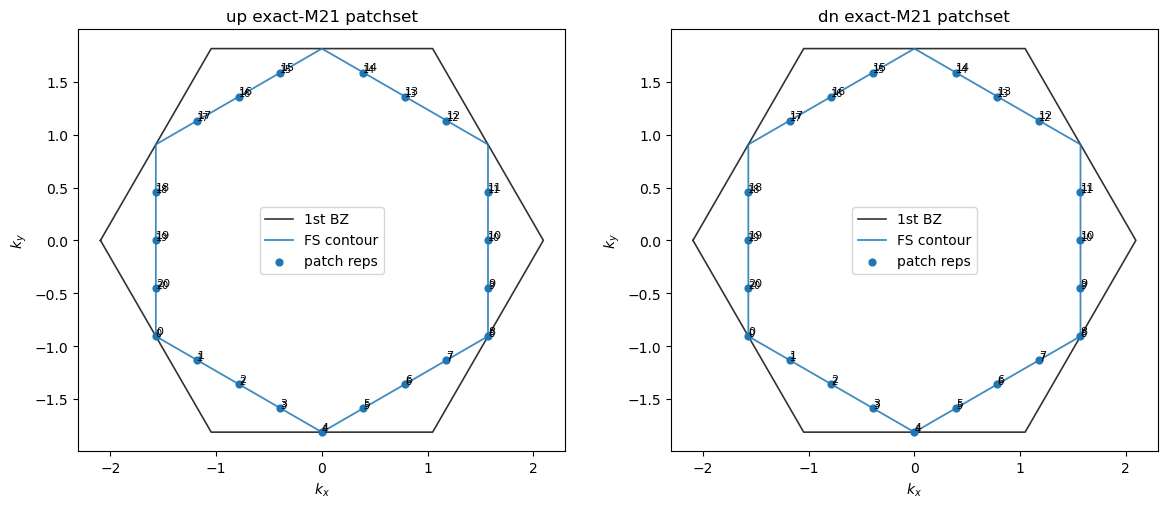

In [8]:

# ============================================================
# Required definitions BEFORE the manual exact-M patch cell
# ============================================================

# Example model params:
MODEL_PARAMS = {"t": 1.0, "phi": np.pi/4}
# If you already defined MODEL_PARAMS elsewhere, keep your own value.

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# Spinful KagomeNagaosa has 6 orbitals total:
#   up sector = first 3
#   dn sector = last 3
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)

# IMPORTANT:
# choose the band index within EACH 3x3 spin block.
# If your previous notebook already had the correct value, use that.
# For many kagome runs the local band index is often 1, but change it if needed.
LOCAL_BAND_INDEX = 1
import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 4           # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

# Model

CASE = U_only  | U = 10.0  V = 0.0
T_START, T_STOP, NFREQ, NSTEPS = 30.0 0.1 40 300
NPATCH = 21
diagnosis_Qs:
  Q0 = (0.000000, 0.000000)
  Q1 = (-1.570796, -0.906900)
  Q2 = (0.000000, -1.813799)
  Q3 = (-1.570796, 0.906900)

solver built.
temperature path length = 300
initial channel norm    = 10.0

=== bare (initial) sign-aware kernel metrics ===


,channel,Q_index,Q,Qx,Qy,eval_pos_max,eval_neg_min,physical_score,chosen_eval,chosen_sign,herm_resid
0,ph_charge,0,"[0.0, 0.0]",0.000000,0.000000,4.000000e+01,-1.724478e-14,1.724478e-14,-1.724478e-14,negative,7.105427e-15
1,ph_spin,0,"[0.0, 0.0]",0.000000,0.000000,9.670735e-15,-7.000000e+01,7.000000e+01,-7.000000e+01,negative,8.881784e-16
2,pp_singlet,0,"[0.0, 0.0]",0.000000,0.000000,2.475503e-14,-1.400000e+02,2.475503e-14,2.475503e-14,positive,3.552714e-15
3,pp_triplet,0,"[0.0, 0.0]",0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,positive,0.000000e+00
4,ph_charge,1,"[-1.5707963267948966, -0.906899682117109]",-1.570796,-0.906900,2.000000e+01,-2.326556e-15,2.326556e-15,-2.326556e-15,negative,8.881784e-16
5,ph_spin,1,"[-1.5707963267948966, -0.906899682117109]",-1.570796,-0.906900,2.326556e-15,-2.000000e+01,2.000000e+01,-2.000000e+01,negative,8.881784e-16
6,pp_singlet,1,"[-1.5707963267948966, -0.906899682117109]",-1.570796,-0.906900,1.256074e-15,-4.000000e+01,1.256074e-15,1.256074e-15,positive,1.776357e-15
7,pp_triplet,1,"[-1.5707963267948966, -0.906899682117109]",-1.570796,-0.906900,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,positive,0.000000e+00
8,ph_charge,2,"[0.0, -1.813799364234218]",0.000000,-1.813799,2.000000e+01,-5.242834e-15,5.242834e-15,-5.242834e-15,negative,4.440892e-16
9,ph_spin,2,"[0.0, -1.813799364234218]",0.000000,-1.813799,5.242834e-15,-2.000000e+01,2.000000e+01,-2.000000e+01,negative,4.440892e-16


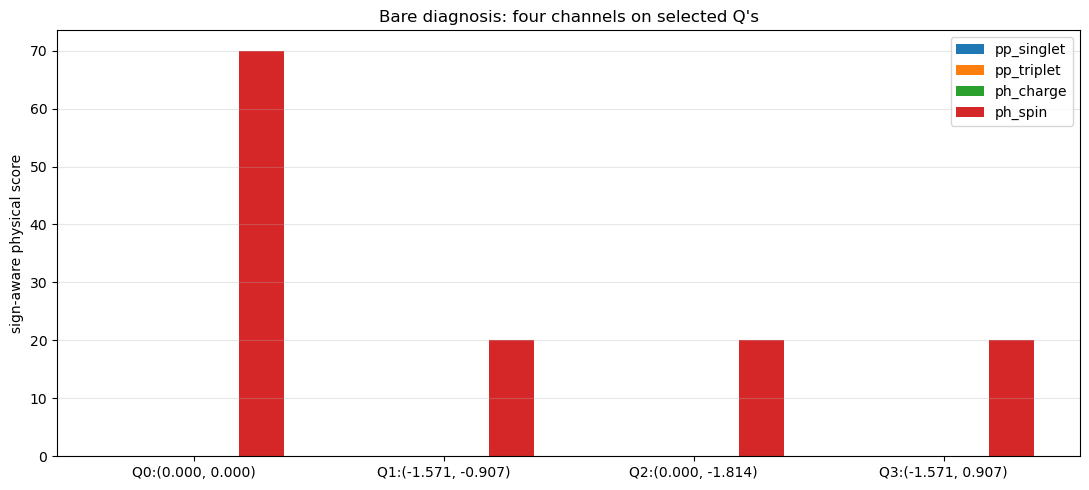


=== bare leader ===
channel : ph_spin
Q       : (0.000000, 0.000000)
score   : 7.000000000000e+01
chosen  : negative -7.000000000000e+01


In [9]:
# ------------------------------------------------------------
# choose interaction case
# ------------------------------------------------------------
CASE = "U_only"   # "V_only" or "U_only" or custom below

if CASE == "V_only":
    U_TEST, V_TEST = 0.0, 8.0
elif CASE == "U_only":
    U_TEST, V_TEST = 10.0, 0.0
else:
    raise ValueError("CASE must be 'V_only' or 'U_only'")

# ------------------------------------------------------------
# flow params
# ------------------------------------------------------------
T_START = 30.0
T_STOP  = 0.1
NFREQ   = 40
NSTEPS  = 300

M6 = exact_M6_points_1bz(model)

# Selected transfer momenta used in diagnosis
diagnosis_Qs = [
    np.array([0.0, 0.0]),
    np.array(M6[0], dtype=float),
    np.array(M6[1], dtype=float),
    np.array(M6[-1], dtype=float),
]

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("NPATCH =", PATCHSETS["up"].Npatch)
print("diagnosis_Qs:")
for i, q in enumerate(diagnosis_Qs):
    print(f"  Q{i} = {fmt_q(q, nd=6)}")

bare_int = BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)
bare_sz0 = BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,
    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,

    # keep the adaptive integrator lenient enough for exploration
    max_relative_update=20.0,
    min_substep_fraction=1.0 / 512.0,

    # do not let raw vertex norm stop the flow too early
    channel_divergence_threshold=1e4,

    # sign-aware diagnosis monitored at selected Q's
    diagnosis_Qs=diagnosis_Qs,
    diagnosis_score_threshold=None,   # set a number later if you want sign-aware early stop
    diagnosis_landau_F=False,
)

print("\nsolver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm    =", solver.state.channel_norm())

# ============================================================
# Bare (initial) kernel metrics at Q=0 and Q=M's
# ============================================================
builder0 = build_sz0_builder_from_solver(solver, Landau_F=False)
df_bare, bare_store = evaluate_selected_Qs(builder0, diagnosis_Qs, landau_F=False)

print("\n=== bare (initial) sign-aware kernel metrics ===")
display(df_bare.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_signaware_bars(df_bare, title="Bare diagnosis: four channels on selected Q's")

best_bare = leading_row_from_df(df_bare)
print("\n=== bare leader ===")
print("channel :", best_bare["channel"])
print("Q       :", fmt_q(best_bare["Q"], nd=6))
print("score   :", f"{best_bare['physical_score']:.12e}")
print("chosen  :", best_bare["chosen_sign"], f"{best_bare['chosen_eval']:.12e}")

# Flow

In [10]:
print("start flow ...")
print("initial T =", solver.state.T)
print("n_steps   =", len(solver.temperature_path))
print("Npatch    =", solver.Npatch)
print()

SNAPSHOT_STEPS = [140, 147, 148, 149]

history, snapshots = manual_run_flow_live(
    solver,
    snapshot_steps=SNAPSHOT_STEPS,
)

print("saved snapshots:", sorted(snapshots.keys()))

print("\nrun finished.")
print("history length =", len(history))
print("instability_record =", solver.instability_record is not None)

if solver.instability_record is not None:
    rec = solver.instability_record
    print("\n=== instability record ===")
    print("step_index        :", rec.step_index)
    print("temperature       :", rec.temperature)
    print("instability       :", rec.instability)
    print("instability_reason:", rec.instability_reason)
    print("termination_reason:", rec.termination_reason)
    print("diagnosis keys    :", list(rec.diagnosis_payload.keys()))
else:
    print("No instability_record found.")

history_df = history_to_dataframe(history)
display(history_df.tail(10))

start flow ...
initial T = 30.0
n_steps   = 300
Npatch    = 21

step=   0 | T=30.000000 | rhs_norm=0.000e+00 | leader=ph_spin @ Q0:(0.000, 0.000) score=7.000e+01 | pp_singlet=2.476e-14, pp_triplet=0.000e+00, ph_charge=1.724e-14, ph_spin=7.000e+01
step=   1 | T=29.900000 | rhs_norm=1.870e-01 | leader=ph_spin @ Q0:(0.000, 0.000) score=6.981e+01 | pp_singlet=5.107e-02, pp_triplet=3.731e-02, ph_charge=5.311e-02, ph_spin=6.981e+01
step=   2 | T=29.800000 | rhs_norm=1.893e-01 | leader=ph_spin @ Q0:(0.000, 0.000) score=6.962e+01 | pp_singlet=1.024e-01, pp_triplet=7.457e-02, ph_charge=1.065e-01, ph_spin=6.962e+01
step=   3 | T=29.700000 | rhs_norm=1.916e-01 | leader=ph_spin @ Q0:(0.000, 0.000) score=6.943e+01 | pp_singlet=1.541e-01, pp_triplet=1.118e-01, ph_charge=1.600e-01, ph_spin=6.943e+01
step=   4 | T=29.600000 | rhs_norm=1.939e-01 | leader=ph_spin @ Q0:(0.000, 0.000) score=6.925e+01 | pp_singlet=2.061e-01, pp_triplet=1.489e-01, ph_charge=2.139e-01, ph_spin=6.925e+01
step=   5 | T=29.5000

,step_index,T,dT,channel_norm,rhs_norm,accepted_substeps,max_rel_update,instability,instability_reason,termination_reason,leading_channel,leading_Q_index,leading_Qx,leading_Qy,leading_score
142,142,15.8,-0.1,5.561050e+01,7.189502e+01,1,0.148086,False,None,None,ph_spin,0,0.0,0.0,8.276271e+01
143,143,15.7,-0.1,6.537189e+01,9.959258e+01,1,0.179090,False,None,None,ph_spin,0,0.0,0.0,9.133436e+01
144,144,15.6,-0.1,7.960549e+01,1.454567e+02,1,0.222507,False,None,None,ph_spin,0,0.0,0.0,1.040467e+02
145,145,15.5,-0.1,1.019018e+02,2.281203e+02,1,0.286564,False,None,None,ph_spin,0,0.0,0.0,1.242740e+02
146,146,15.4,-0.1,1.405141e+02,3.953360e+02,1,0.387958,False,None,None,ph_spin,0,0.0,0.0,1.598158e+02
147,147,15.3,-0.1,2.180562e+02,7.940956e+02,1,0.565136,False,None,None,ph_spin,0,0.0,0.0,2.321808e+02
148,148,15.2,-0.1,4.179586e+02,2.014065e+03,1,0.923645,False,None,None,ph_charge,0,0.0,0.0,4.310427e+02
149,149,15.1,-0.1,1.180757e+03,7.627988e+03,1,1.825058,False,None,None,ph_charge,0,0.0,0.0,1.213112e+03
150,150,15.0,-0.1,7.365471e+03,6.184714e+04,1,5.237921,False,None,None,ph_charge,0,0.0,0.0,7.563659e+03
151,151,14.9,-0.1,3.820048e+07,7.614193e+08,2,293.956326,True,channel norm=3.820e+07 exceeded channel_diverg...,None,ph_charge,0,0.0,0.0,3.941084e+07


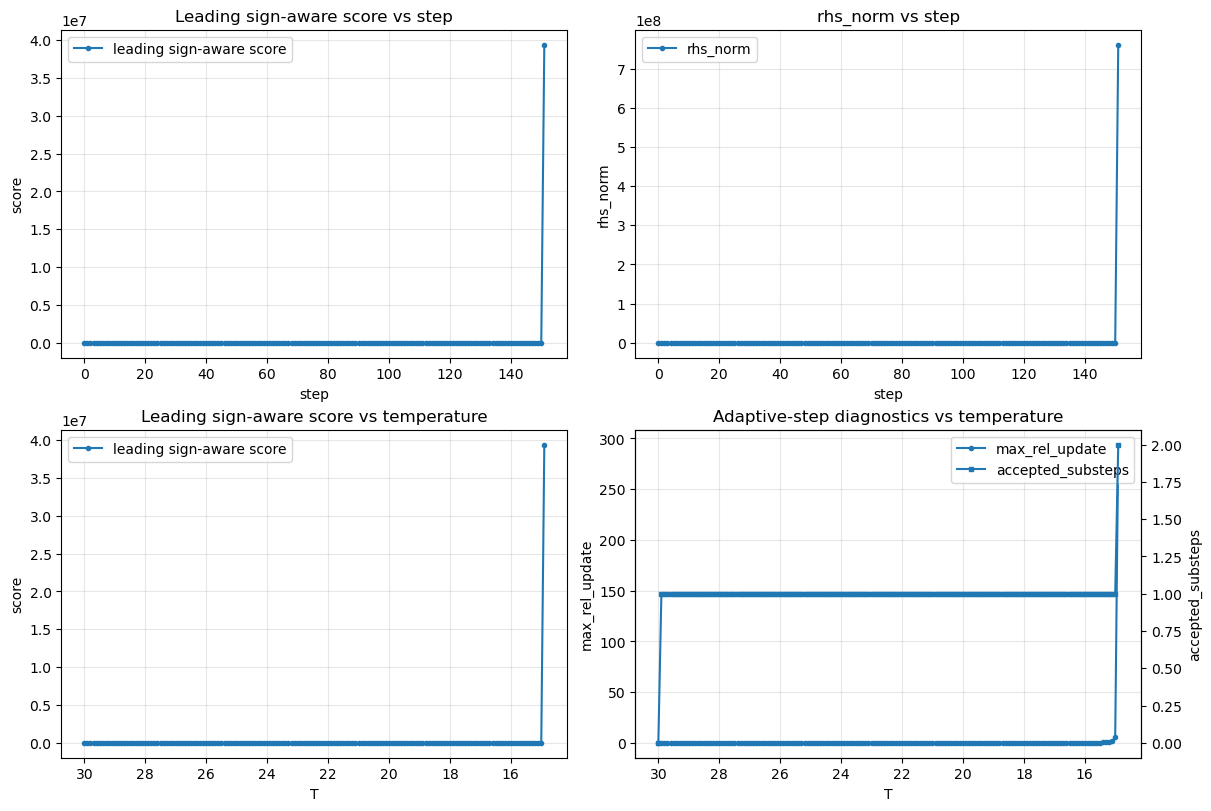

In [11]:
# ============================================================
# Flow history plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0,0].plot(history_df["step_index"], history_df["leading_score"], marker="o", ms=3, label="leading sign-aware score")
axes[0,0].set_title("Leading sign-aware score vs step")
axes[0,0].set_xlabel("step")
axes[0,0].set_ylabel("score")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

axes[0,1].plot(history_df["step_index"], history_df["rhs_norm"], marker="o", ms=3, label="rhs_norm")
axes[0,1].set_title("rhs_norm vs step")
axes[0,1].set_xlabel("step")
axes[0,1].set_ylabel("rhs_norm")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

axes[1,0].plot(history_df["T"], history_df["leading_score"], marker="o", ms=3, label="leading sign-aware score")
axes[1,0].invert_xaxis()
axes[1,0].set_title("Leading sign-aware score vs temperature")
axes[1,0].set_xlabel("T")
axes[1,0].set_ylabel("score")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

ax = axes[1,1]
ax.plot(history_df["T"], history_df["max_rel_update"], marker="o", ms=3, label="max_rel_update")
ax.invert_xaxis()
ax.set_xlabel("T")
ax.set_ylabel("max_rel_update")
ax.grid(True, alpha=0.3)
ax2 = ax.twinx()
ax2.plot(history_df["T"], history_df["accepted_substeps"], marker="s", ms=3, label="accepted_substeps")
ax2.set_ylabel("accepted_substeps")
ax.set_title("Adaptive-step diagnostics vs temperature")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.show()

# Final diagnosis

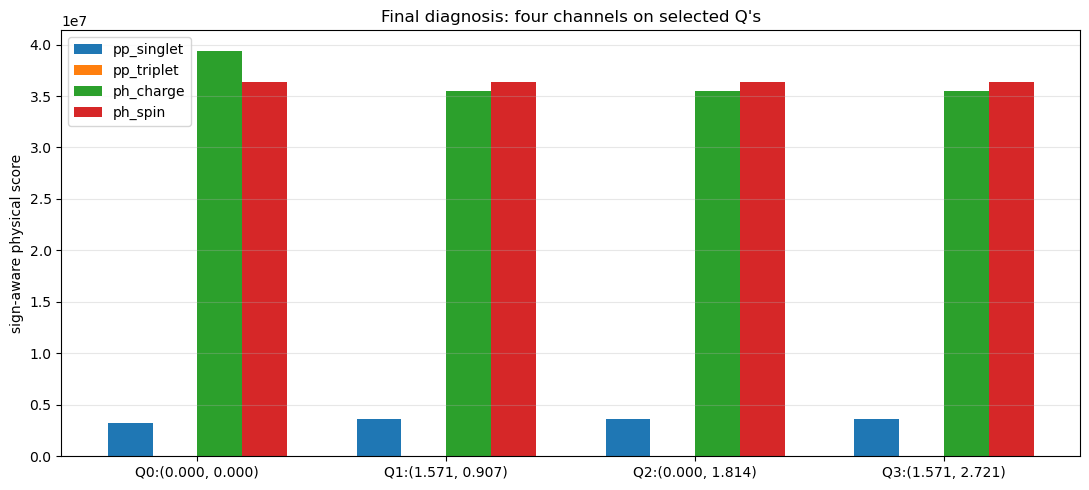


=== leader eigenstate summary ===
channel            : ph_charge
Q                  : (0.000000, 0.000000)
selected eigenvalue: -3.941084483806e+07
kernel dimension   : 21
|<u_const|v>|      : 2.394841676845e-17


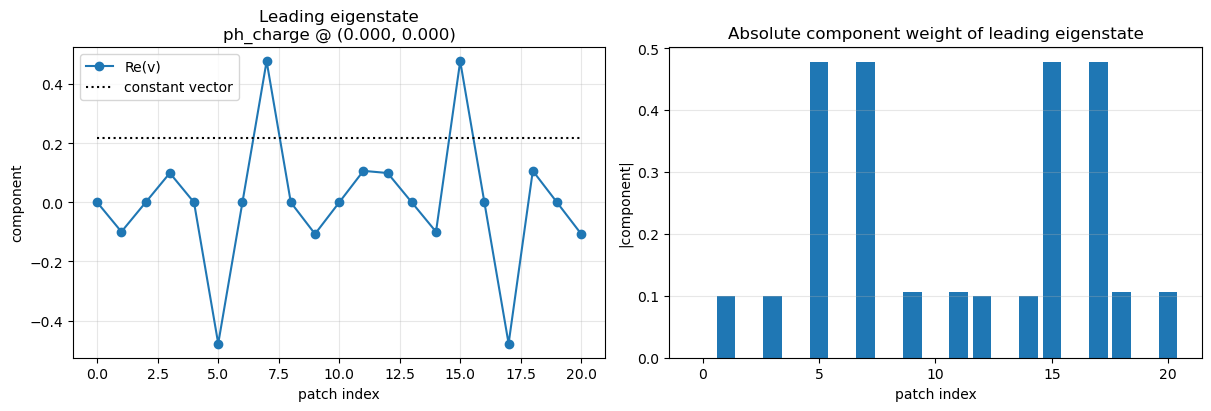

In [12]:
# ============================================================
# Final diagnosis on selected Q's
#   - bar chart
#   - maximal kernel eigenstate
# ============================================================
last_rec = solver.history[-1]
payload = last_rec.diagnosis_payload

if "sign_aware" not in payload:
    raise RuntimeError(
        "No sign_aware diagnosis found in solver.history[-1]. "
        "Please make sure diagnosis_Qs was passed into the solver."
    )

sa = payload["sign_aware"]
df_final = pd.DataFrame(sa["rows"])
# display(df_final.sort_values(["Q_index", "channel"]).reset_index(drop=True))

plot_signaware_bars(df_final, title="Final diagnosis: four channels on selected Q's")

# print("\n=== final leader ===")
# print("channel :", sa["leading_channel"])
# print("Q       :", fmt_q(sa["leading_Q"], nd=6))
# print("score   :", f"{sa['leading_score']:.12e}")
# print("chosen  :", sa["leading_chosen_sign"], f"{sa['leading_chosen_eval']:.12e}")

# Rebuild final kernels from the current solver state
builder_final = build_sz0_builder_from_solver(solver, Landau_F=False)
kernel_dict = builder_final.build_kernel_dict(np.asarray(sa["leading_Q"], dtype=float), Landau_F=False)
lead_kernel = kernel_dict[sa["leading_channel"]]

lead_val, lead_vec = choose_signaware_eigenpair(sa["leading_channel"], lead_kernel.matrix)

# Fix the global phase for readability
imax = int(np.argmax(np.abs(lead_vec)))
phase = np.angle(lead_vec[imax]) if np.abs(lead_vec[imax]) > 1e-14 else 0.0
lead_vec = lead_vec * np.exp(-1j * phase)

print("\n=== leader eigenstate summary ===")
print("channel            :", sa["leading_channel"])
print("Q                  :", fmt_q(sa["leading_Q"], nd=6))
print("selected eigenvalue:", f"{lead_val:.12e}")
print("kernel dimension   :", len(lead_vec))

u_const = np.ones(len(lead_vec), dtype=complex) / np.sqrt(len(lead_vec))
const_overlap = abs(np.vdot(u_const, lead_vec))
print("|<u_const|v>|      :", f"{const_overlap:.12e}")

df_eig = pd.DataFrame({
    "patch": np.arange(len(lead_vec)),
    "vec_real": np.real(lead_vec),
    "vec_imag": np.imag(lead_vec),
    "vec_abs": np.abs(lead_vec),
    "const_real": np.real(u_const),
})
# display(df_eig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(np.arange(len(lead_vec)), np.real(lead_vec), "o-", label="Re(v)")
if np.max(np.abs(np.imag(lead_vec))) > 1e-10:
    axes[0].plot(np.arange(len(lead_vec)), np.imag(lead_vec), "s--", label="Im(v)")
axes[0].plot(np.arange(len(lead_vec)), np.real(u_const), "k:", label="constant vector")
axes[0].set_title(f"Leading eigenstate\n{sa['leading_channel']} @ {fmt_q(sa['leading_Q'])}")
axes[0].set_xlabel("patch index")
axes[0].set_ylabel("component")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(np.arange(len(lead_vec)), np.abs(lead_vec))
axes[1].set_title("Absolute component weight of leading eigenstate")
axes[1].set_xlabel("patch index")
axes[1].set_ylabel("|component|")
axes[1].grid(True, axis="y", alpha=0.3)

plt.show()

# Instability

In [13]:
results_1, df_inst_1 = diagnose_snapshot_instabilities(
    snapshots[140], solver, diagnosis_Qs
)
results_2, df_inst_2 = diagnose_snapshot_instabilities(
    snapshots[147], solver, diagnosis_Qs
)
results_3, df_inst_3 = diagnose_snapshot_instabilities(
    snapshots[148], solver, diagnosis_Qs
)
results_4, df_inst_4 = diagnose_snapshot_instabilities(
    snapshots[149], solver, diagnosis_Qs
)
# display(df_inst_1.sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(df_inst_2.sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(df_inst_3.sort_values(["Q_index", "channel"]).reset_index(drop=True))
# display(df_inst_4.sort_values(["Q_index", "channel"]).reset_index(drop=True))

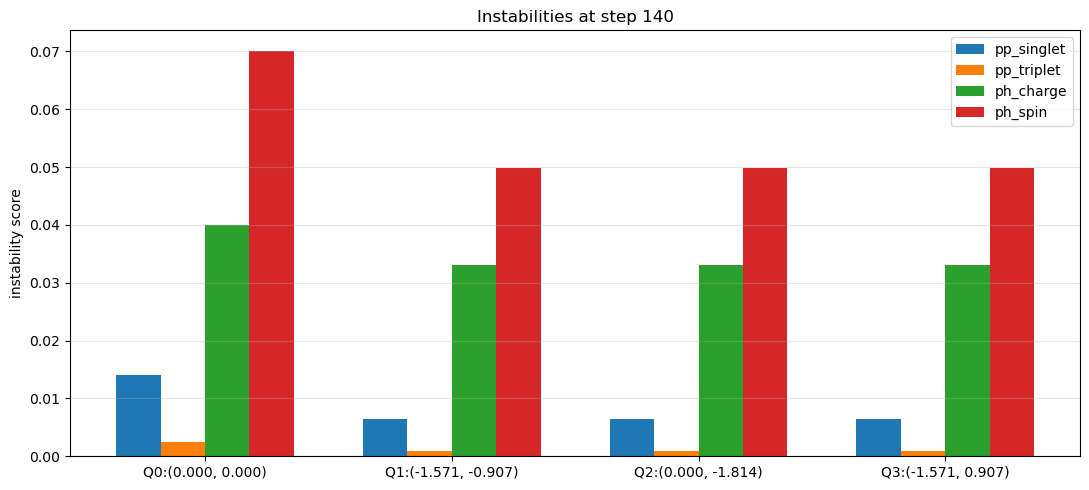

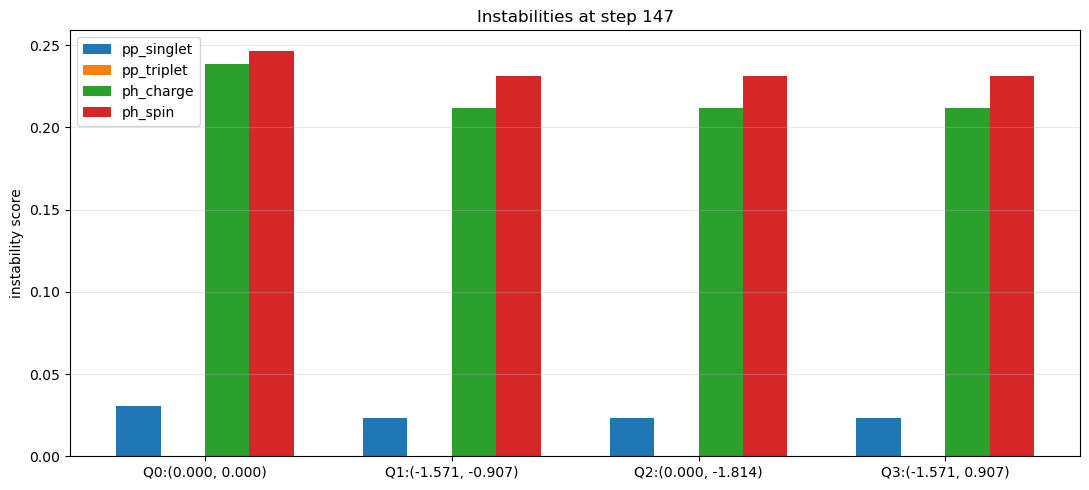

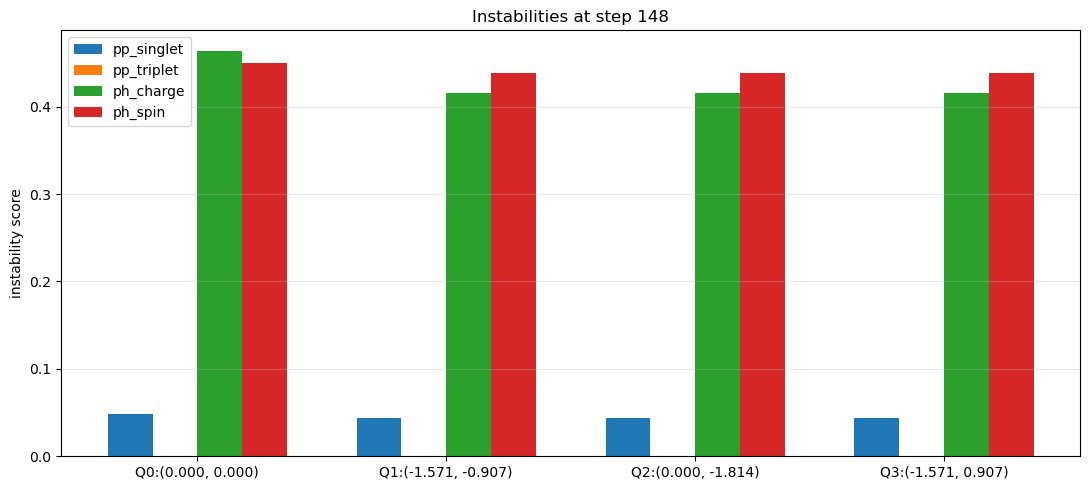

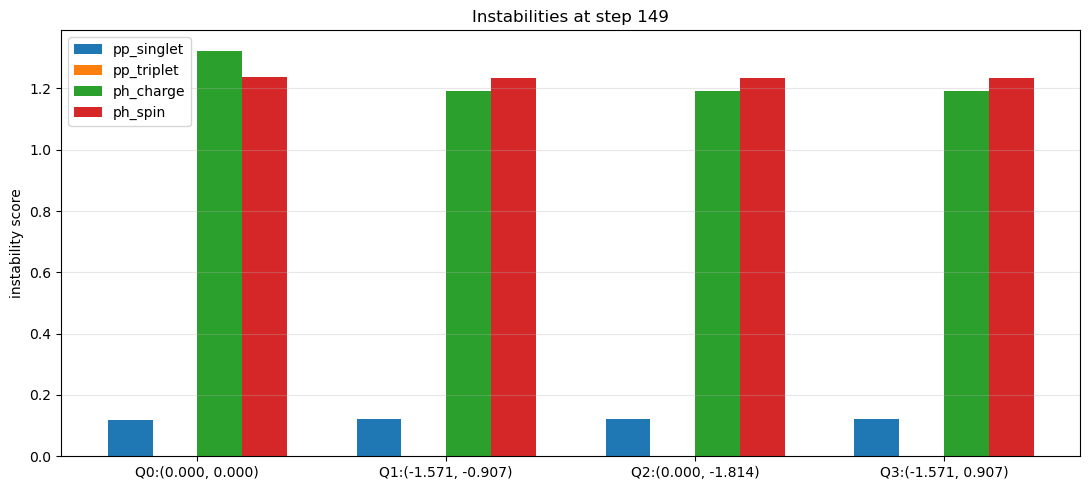

In [14]:
plot_instability_bars(df_inst_1, title="Instabilities at step 140")
plot_instability_bars(df_inst_2, title="Instabilities at step 147")
plot_instability_bars(df_inst_3, title="Instabilities at step 148")
plot_instability_bars(df_inst_4, title="Instabilities at step 149")

# Debug

In [20]:
# ============================================================
# Cell 1
# 一个更通用的 instability diagnosis helper
# 允许你切换 projector / bubble mode
# ============================================================
def diagnose_snapshot_instabilities_cfg(
    snapshot, solver, diagnosis_Qs, *,
    temperature=None,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
    project_pp_singlet_q0_local_gram_default=False,
):
    import numpy as np
    import pandas as pd

    if temperature is None:
        temperature = snapshot.T

    builder = make_builder_from_snapshot(snapshot, solver)

    cfg = InstabilityConfig(
        ph_sign=-1,
        pp_sign=+1,
        use_hermitian_part=True,
        bubble_floor=0.0,
        ph_bubble_mode=ph_bubble_mode,
        project_ph_charge_q0_uniform=project_ph_charge_q0_uniform,
        report_pp_singlet_q0_local_gram_both=True,
        project_pp_singlet_q0_local_gram_default=project_pp_singlet_q0_local_gram_default,
        store_operator_matrices=True,
        store_all_evals=False,
    )

    flow_cfg = FlowConfig(
        temperature=float(temperature),
        nfreq=solver.nfreq,
        include_explicit_T_prefactor=solver.include_explicit_T_prefactor,
    )

    results_by_Q = {}
    rows = []

    for iq, Q in enumerate(diagnosis_Qs):
        kernel_dict = builder.build_kernel_dict(np.asarray(Q, dtype=float), Landau_F=False)

        res_dict = diagnose_kernel_collection(
            kernel_dict,
            solver.patchsets,
            solver.transfer_context(),
            flow_cfg,
            config=cfg,
        )
        results_by_Q[iq] = res_dict

        for ch_name, res in res_dict.items():
            rows.append({
                "snapshot": snapshot.label,
                "T": float(snapshot.T),
                "Q_index": iq,
                "Q": np.asarray(Q, dtype=float),
                "channel": ch_name,
                "score": float(res.score),
                "leading_eval": float(res.leading_eval),
                "score_unprojected": float(res.score_unprojected),
                "score_projected": None if res.score_projected is None else float(res.score_projected),
                "projection_name": res.projection_name,
                "bubble_source": res.bubble.source,
                "channel_type": res.channel_type,
                "spin_structure": res.spin_structure,
                "notes": list(res.notes),
            })

    summary_df = pd.DataFrame(rows)
    return results_by_Q, summary_df

In [21]:
# ============================================================
# Cell 2
# 画 instability 柱状图
# ============================================================
def plot_instability_bars(df, *, title):
    import numpy as np
    import matplotlib.pyplot as plt

    df = df.copy()
    df["Q_key"] = df["Q"].apply(lambda x: tuple(np.asarray(x, dtype=float)))
    q_keys = list(dict.fromkeys(df["Q_key"].tolist()))
    q_labels = [f"Q{i}:{fmt_q(np.array(qk))}" for i, qk in enumerate(q_keys)]

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for qk in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_key"] == qk)]
            vals.append(float(sub.iloc[0]["score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("instability score")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [22]:
# ============================================================
# Cell 3
# A/B test 1:
# 比较 project_ph_charge_q0_uniform = True / False
# 先拿最后一个你关心的 snapshot，比如 148 或 149
# ============================================================
STEP_TO_TEST = 148   # 改成 147 / 148 / 149 都行

res_proj_on, df_proj_on = diagnose_snapshot_instabilities_cfg(
    snapshots[STEP_TO_TEST],
    solver,
    diagnosis_Qs,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
)

res_proj_off, df_proj_off = diagnose_snapshot_instabilities_cfg(
    snapshots[STEP_TO_TEST],
    solver,
    diagnosis_Qs,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=False,
)

print("=== projector ON ===")
display(df_proj_on.sort_values(["Q_index", "channel"]).reset_index(drop=True))

print("=== projector OFF ===")
display(df_proj_off.sort_values(["Q_index", "channel"]).reset_index(drop=True))

=== projector ON ===


,snapshot,T,Q_index,Q,channel,score,leading_eval,score_unprojected,score_projected,projection_name,bubble_source,channel_type,spin_structure,notes
0,step_148,15.2,0,"[0.0, 0.0]",ph_charge,4.640817e-01,4.640817e-01,4.640817e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,"[ph_bubble_mode=patchrep, ph_charge_q0_kernel_..."
1,step_148,15.2,0,"[0.0, 0.0]",ph_spin,4.503906e-01,4.503906e-01,4.503906e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
2,step_148,15.2,0,"[0.0, 0.0]",pp_singlet,4.866020e-02,4.866020e-02,4.866020e-02,0.044465,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,"[pp_operator_uses_abs_bubble_weights, projecti..."
3,step_148,15.2,0,"[0.0, 0.0]",pp_triplet,1.605519e-17,1.605519e-17,1.605519e-17,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
4,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
5,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
6,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_singlet,4.340716e-02,4.340716e-02,4.340716e-02,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,[pp_operator_uses_abs_bubble_weights]
7,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_triplet,4.010190e-18,4.010190e-18,4.010190e-18,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
8,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
9,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]


=== projector OFF ===


,snapshot,T,Q_index,Q,channel,score,leading_eval,score_unprojected,score_projected,projection_name,bubble_source,channel_type,spin_structure,notes
0,step_148,15.2,0,"[0.0, 0.0]",ph_charge,4.640817e-01,4.640817e-01,4.640817e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
1,step_148,15.2,0,"[0.0, 0.0]",ph_spin,4.503906e-01,4.503906e-01,4.503906e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
2,step_148,15.2,0,"[0.0, 0.0]",pp_singlet,4.866020e-02,4.866020e-02,4.866020e-02,0.044465,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,"[pp_operator_uses_abs_bubble_weights, projecti..."
3,step_148,15.2,0,"[0.0, 0.0]",pp_triplet,1.605519e-17,1.605519e-17,1.605519e-17,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
4,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
5,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
6,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_singlet,4.340716e-02,4.340716e-02,4.340716e-02,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,[pp_operator_uses_abs_bubble_weights]
7,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_triplet,4.010190e-18,4.010190e-18,4.010190e-18,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
8,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
9,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]


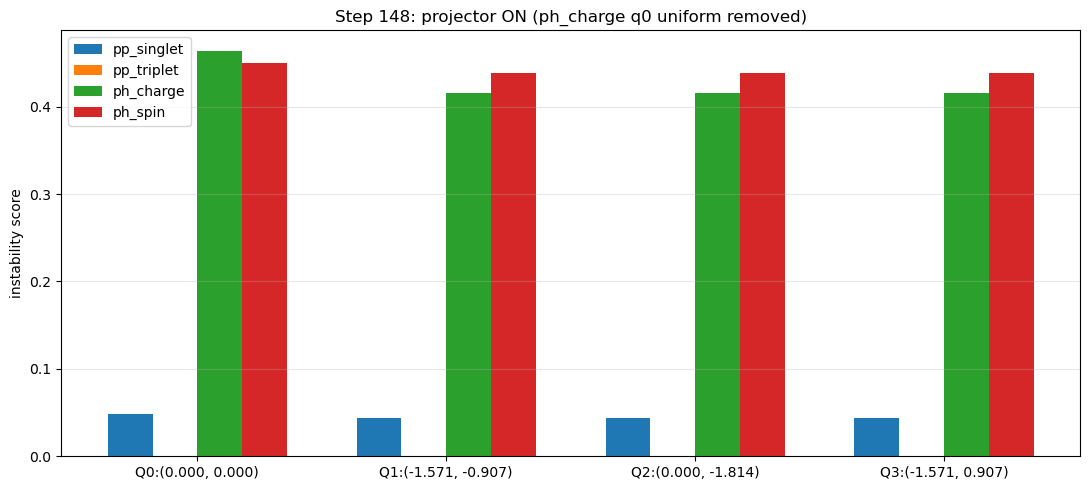

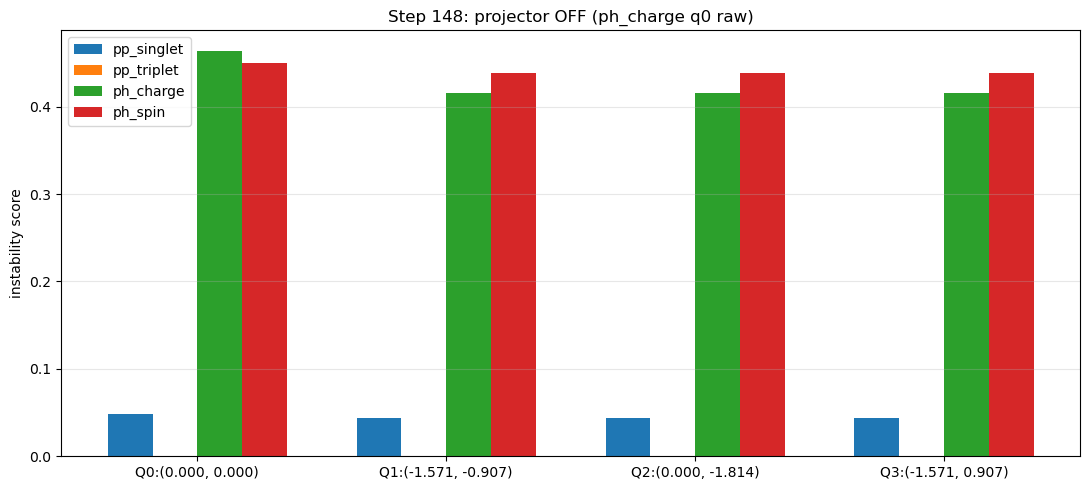

In [23]:
# ============================================================
# Cell 4
# 画 A/B test 1 的柱状图
# ============================================================
plot_instability_bars(
    df_proj_on,
    title=f"Step {STEP_TO_TEST}: projector ON (ph_charge q0 uniform removed)"
)

plot_instability_bars(
    df_proj_off,
    title=f"Step {STEP_TO_TEST}: projector OFF (ph_charge q0 raw)"
)

In [24]:
# ============================================================
# Cell 5
# A/B test 1 的数值对比，只盯 Q=0
# ============================================================
import pandas as pd
import numpy as np

def q0_compare(dfA, labelA, dfB, labelB):
    A = dfA[dfA["Q_index"] == 0][["channel","score","projection_name","bubble_source"]].copy()
    A = A.rename(columns={
        "score": f"score_{labelA}",
        "projection_name": f"projection_{labelA}",
        "bubble_source": f"bubble_{labelA}",
    })

    B = dfB[dfB["Q_index"] == 0][["channel","score","projection_name","bubble_source"]].copy()
    B = B.rename(columns={
        "score": f"score_{labelB}",
        "projection_name": f"projection_{labelB}",
        "bubble_source": f"bubble_{labelB}",
    })

    out = A.merge(B, on="channel", how="outer")
    if f"score_{labelA}" in out.columns and f"score_{labelB}" in out.columns:
        out["ratio_B_over_A"] = out[f"score_{labelB}"] / (out[f"score_{labelA}"] + 1e-300)
    return out

cmp_proj = q0_compare(df_proj_on, "proj_on", df_proj_off, "proj_off")
display(cmp_proj)

,channel,score_proj_on,projection_proj_on,bubble_proj_on,score_proj_off,projection_proj_off,bubble_proj_off,ratio_B_over_A
0,ph_charge,4.640817e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",4.640817e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",1.0
1,ph_spin,4.503906e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",4.503906e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",1.0
2,pp_singlet,4.866020e-02,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",4.866020e-02,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",1.0
3,pp_triplet,1.605519e-17,None,"build_pp_internal_cache_vec[(up,dn)]",1.605519e-17,None,"build_pp_internal_cache_vec[(up,dn)]",1.0


In [25]:
# ============================================================
# Cell 6
# A/B test 2:
# 比较 ph_bubble_mode = patchrep / internal_cache
# ============================================================
STEP_TO_TEST = 148   # 可改

res_patchrep, df_patchrep = diagnose_snapshot_instabilities_cfg(
    snapshots[STEP_TO_TEST],
    solver,
    diagnosis_Qs,
    ph_bubble_mode="patchrep",
    project_ph_charge_q0_uniform=True,
)

res_internal, df_internal = diagnose_snapshot_instabilities_cfg(
    snapshots[STEP_TO_TEST],
    solver,
    diagnosis_Qs,
    ph_bubble_mode="internal_cache",
    project_ph_charge_q0_uniform=True,
)

print("=== ph_bubble_mode = patchrep ===")
display(df_patchrep.sort_values(["Q_index", "channel"]).reset_index(drop=True))

print("=== ph_bubble_mode = internal_cache ===")
display(df_internal.sort_values(["Q_index", "channel"]).reset_index(drop=True))

=== ph_bubble_mode = patchrep ===


,snapshot,T,Q_index,Q,channel,score,leading_eval,score_unprojected,score_projected,projection_name,bubble_source,channel_type,spin_structure,notes
0,step_148,15.2,0,"[0.0, 0.0]",ph_charge,4.640817e-01,4.640817e-01,4.640817e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,"[ph_bubble_mode=patchrep, ph_charge_q0_kernel_..."
1,step_148,15.2,0,"[0.0, 0.0]",ph_spin,4.503906e-01,4.503906e-01,4.503906e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
2,step_148,15.2,0,"[0.0, 0.0]",pp_singlet,4.866020e-02,4.866020e-02,4.866020e-02,0.044465,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,"[pp_operator_uses_abs_bubble_weights, projecti..."
3,step_148,15.2,0,"[0.0, 0.0]",pp_triplet,1.605519e-17,1.605519e-17,1.605519e-17,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
4,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
5,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]
6,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_singlet,4.340716e-02,4.340716e-02,4.340716e-02,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,[pp_operator_uses_abs_bubble_weights]
7,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_triplet,4.010190e-18,4.010190e-18,4.010190e-18,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
8,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,charge,[ph_bubble_mode=patchrep]
9,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",ph,spin,[ph_bubble_mode=patchrep]


=== ph_bubble_mode = internal_cache ===


,snapshot,T,Q_index,Q,channel,score,leading_eval,score_unprojected,score_projected,projection_name,bubble_source,channel_type,spin_structure,notes
0,step_148,15.2,0,"[0.0, 0.0]",ph_charge,4.640817e-01,4.640817e-01,4.640817e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,charge,[ph_charge_q0_kernel_already_reduced_upstream;...
1,step_148,15.2,0,"[0.0, 0.0]",ph_spin,4.503906e-01,4.503906e-01,4.503906e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,spin,[]
2,step_148,15.2,0,"[0.0, 0.0]",pp_singlet,4.866020e-02,4.866020e-02,4.866020e-02,0.044465,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,"[pp_operator_uses_abs_bubble_weights, projecti..."
3,step_148,15.2,0,"[0.0, 0.0]",pp_triplet,1.605519e-17,1.605519e-17,1.605519e-17,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
4,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,charge,[]
5,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,spin,[]
6,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_singlet,4.340716e-02,4.340716e-02,4.340716e-02,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,singlet,[pp_operator_uses_abs_bubble_weights]
7,step_148,15.2,1,"[-1.5707963267948966, -0.906899682117109]",pp_triplet,4.010190e-18,4.010190e-18,4.010190e-18,NaN,None,"build_pp_internal_cache_vec[(up,dn)]",pp,triplet,[pp_operator_uses_abs_bubble_weights]
8,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_charge,4.155393e-01,4.155393e-01,4.155393e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,charge,[]
9,step_148,15.2,2,"[0.0, -1.813799364234218]",ph_spin,4.387111e-01,4.387111e-01,4.387111e-01,NaN,None,"build_ph_internal_cache_vec[(up,dn)]",ph,spin,[]


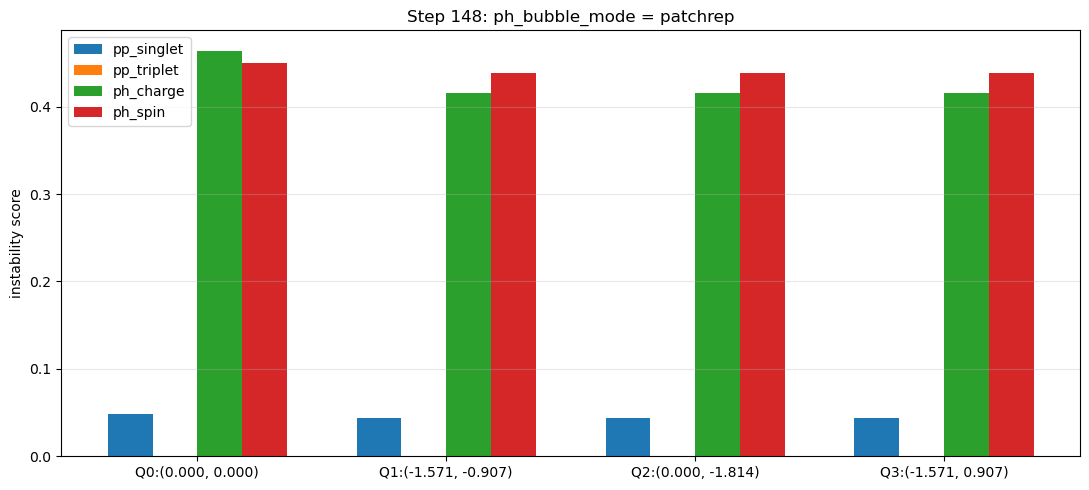

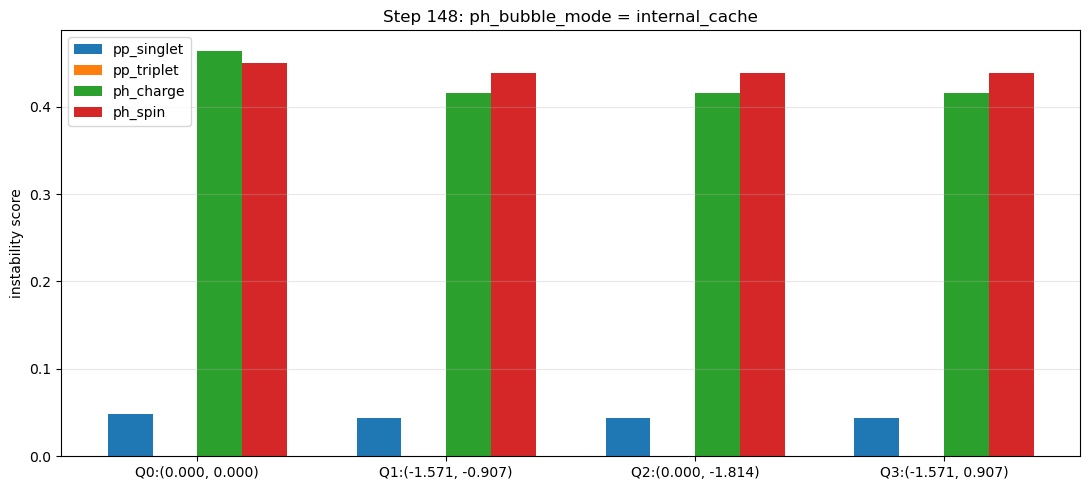

In [26]:
# ============================================================
# Cell 7
# 画 A/B test 2 的柱状图
# ============================================================
plot_instability_bars(
    df_patchrep,
    title=f"Step {STEP_TO_TEST}: ph_bubble_mode = patchrep"
)

plot_instability_bars(
    df_internal,
    title=f"Step {STEP_TO_TEST}: ph_bubble_mode = internal_cache"
)

In [27]:
# ============================================================
# Cell 8
# A/B test 2 的数值对比，只盯 Q=0
# ============================================================
cmp_bubble = q0_compare(df_patchrep, "patchrep", df_internal, "internal")
display(cmp_bubble)

,channel,score_patchrep,projection_patchrep,bubble_patchrep,score_internal,projection_internal,bubble_internal,ratio_B_over_A
0,ph_charge,4.640817e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",4.640817e-01,None,"build_ph_internal_cache_vec[(up,dn)]",1.0
1,ph_spin,4.503906e-01,None,"patchrep:bubble_dot_ph(eps_p,eps_p+Q)",4.503906e-01,None,"build_ph_internal_cache_vec[(up,dn)]",1.0
2,pp_singlet,4.866020e-02,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",4.866020e-02,local_gram_q0_pp_singlet,"build_pp_internal_cache_vec[(up,dn)]",1.0
3,pp_triplet,1.605519e-17,None,"build_pp_internal_cache_vec[(up,dn)]",1.605519e-17,None,"build_pp_internal_cache_vec[(up,dn)]",1.0


In [28]:
# ============================================================
# Cell 9
# 取某个 snapshot，构造 Vd / Vx
# ============================================================
STEP_TO_TEST = 148   # 改成 147 / 148 / 149 都可以
Q_INDEX_TO_TEST = 0  # 先看 Q=0

snapshot = snapshots[STEP_TO_TEST]
Q_test = np.asarray(diagnosis_Qs[Q_INDEX_TO_TEST], dtype=float)

builder = make_builder_from_snapshot(snapshot, solver)

ker_vd = builder.ph_direct(Q_test)
ker_vx = builder.ph_exchange(Q_test)

print("snapshot =", snapshot.label, "T =", snapshot.T)
print("Q_test   =", Q_test)

print("\nVd hermitian residual =", ker_vd.hermitian_residual())
print("Vx hermitian residual =", ker_vx.hermitian_residual())

print("Vd shape =", ker_vd.matrix.shape)
print("Vx shape =", ker_vx.matrix.shape)

snapshot = step_148 T = 15.200000000000001
Q_test   = [0. 0.]

Vd hermitian residual = 8.881784197001256e-16
Vx hermitian residual = 3.552713678800534e-15
Vd shape = (21, 21)
Vx shape = (21, 21)


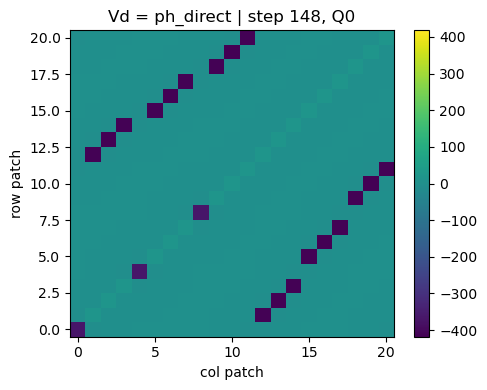

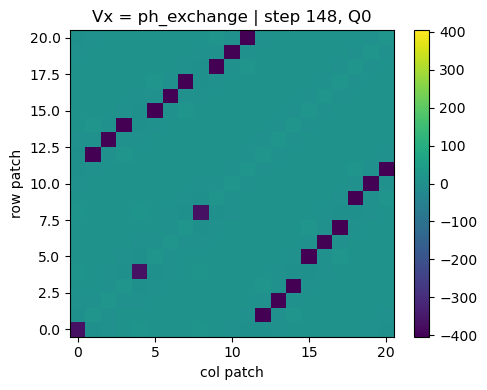

In [29]:
# ============================================================
# Cell 10
# 看 Vd / Vx 的矩阵热图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_matrix_heatmap(M, title, vlim=None):
    M = np.asarray(M)
    if np.iscomplexobj(M):
        Mplot = np.real_if_close(M, tol=1000)
        if np.iscomplexobj(Mplot):
            Mplot = np.real(M)
    else:
        Mplot = M

    plt.figure(figsize=(5,4))
    if vlim is None:
        vmax = np.max(np.abs(Mplot)) if Mplot.size else 1.0
        vmin = -vmax
    else:
        vmin, vmax = vlim
    plt.imshow(Mplot, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("col patch")
    plt.ylabel("row patch")
    plt.tight_layout()
    plt.show()

plot_matrix_heatmap(ker_vd.matrix, f"Vd = ph_direct | step {STEP_TO_TEST}, Q{Q_INDEX_TO_TEST}")
plot_matrix_heatmap(ker_vx.matrix, f"Vx = ph_exchange | step {STEP_TO_TEST}, Q{Q_INDEX_TO_TEST}")

Vd eig min/max = -418.3262886246938 437.77910037558746
Vx eig min/max = -422.011969119681 429.91648853694244


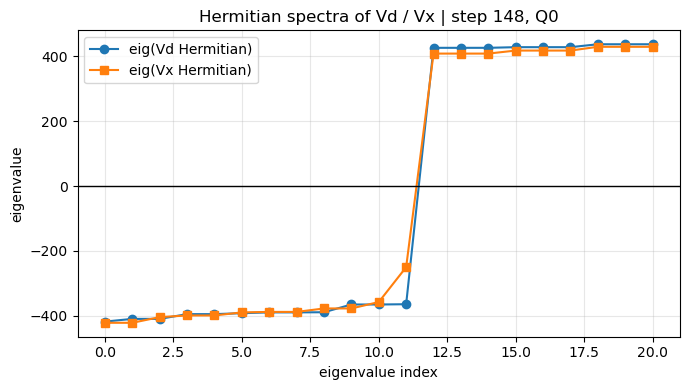

In [30]:
# ============================================================
# Cell 11
# 看 Vd / Vx 的 Hermitian part 谱
# ============================================================
def hermitian_part(M):
    M = np.asarray(M, dtype=complex)
    return 0.5 * (M + M.conjugate().T)

Hd = hermitian_part(ker_vd.matrix)
Hx = hermitian_part(ker_vx.matrix)

evals_d, _ = np.linalg.eigh(Hd)
evals_x, _ = np.linalg.eigh(Hx)

print("Vd eig min/max =", float(np.min(evals_d)), float(np.max(evals_d)))
print("Vx eig min/max =", float(np.min(evals_x)), float(np.max(evals_x)))

plt.figure(figsize=(7,4))
plt.plot(np.sort(evals_d), "o-", label="eig(Vd Hermitian)")
plt.plot(np.sort(evals_x), "s-", label="eig(Vx Hermitian)")
plt.axhline(0.0, color="k", linewidth=1)
plt.title(f"Hermitian spectra of Vd / Vx | step {STEP_TO_TEST}, Q{Q_INDEX_TO_TEST}")
plt.xlabel("eigenvalue index")
plt.ylabel("eigenvalue")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

||Hspin||_F   = 1872.5357301494398
||Hcharge||_F = 1802.354907060331
||Delta||_F   = 3649.9956389002664
relative ||Delta|| / ||Hspin|| = 1.9492261643568074


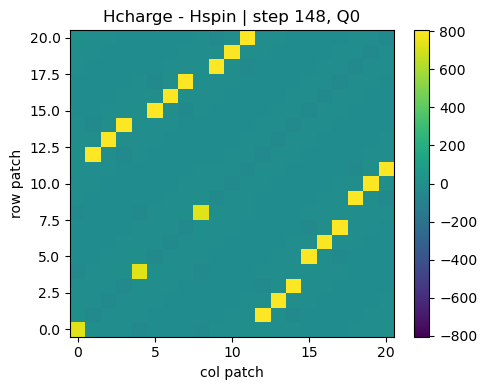

In [31]:
# ============================================================
# Cell 12
# 直接看 charge / spin 的关系：
#   ph_charge = Vd - 2 Vx
#   ph_spin   = Vd
# 所以真正的差别来自 2Vx
# ============================================================
Hcharge = hermitian_part(builder.ph_charge(Q_test, Landau_F=False).matrix)
Hspin   = hermitian_part(builder.ph_spin(Q_test).matrix)

Delta = Hcharge - Hspin   # should be approximately -2 Vx in diagnosis convention

print("||Hspin||_F   =", np.linalg.norm(Hspin))
print("||Hcharge||_F =", np.linalg.norm(Hcharge))
print("||Delta||_F   =", np.linalg.norm(Delta))
print("relative ||Delta|| / ||Hspin|| =", np.linalg.norm(Delta) / (np.linalg.norm(Hspin) + 1e-300))

plot_matrix_heatmap(Delta, f"Hcharge - Hspin | step {STEP_TO_TEST}, Q{Q_INDEX_TO_TEST}")

In [32]:
# ============================================================
# Cell 13
# 扫描最后几步（比如 147,148,149）的 Vd / Vx 大小
# 只看 Q=0
# ============================================================
rows = []
for step in [147, 148, 149]:
    if step not in snapshots:
        continue
    snap = snapshots[step]
    b = make_builder_from_snapshot(snap, solver)
    Q0 = np.asarray(diagnosis_Qs[0], dtype=float)

    vd = b.ph_direct(Q0).matrix
    vx = b.ph_exchange(Q0).matrix

    Hd = hermitian_part(vd)
    Hx = hermitian_part(vx)

    rows.append({
        "step": step,
        "T": snap.T,
        "||Vd||_F": np.linalg.norm(vd),
        "||Vx||_F": np.linalg.norm(vx),
        "||Hd||_F": np.linalg.norm(Hd),
        "||Hx||_F": np.linalg.norm(Hx),
        "ratio ||Hx|| / ||Hd||": np.linalg.norm(Hx) / (np.linalg.norm(Hd) + 1e-300),
        "eigmin(Hd)": float(np.min(np.linalg.eigvalsh(Hd))),
        "eigmax(Hd)": float(np.max(np.linalg.eigvalsh(Hd))),
        "eigmin(Hx)": float(np.min(np.linalg.eigvalsh(Hx))),
        "eigmax(Hx)": float(np.max(np.linalg.eigvalsh(Hx))),
    })

import pandas as pd
df_vd_vx = pd.DataFrame(rows)
display(df_vd_vx)

,step,T,||Vd||_F,||Vx||_F,||Hd||_F,||Hx||_F,ratio ||Hx|| / ||Hd||,eigmin(Hd),eigmax(Hd),eigmin(Hx),eigmax(Hx)
0,147,15.3,976.577865,956.416601,976.577865,956.416601,0.979355,-232.180821,227.590240,-232.482183,223.232724
1,148,15.2,1872.535730,1830.309319,1872.535730,1830.309319,0.977450,-418.326289,437.779100,-422.011969,429.916489
2,149,15.1,5270.161109,5146.820476,5270.161109,5146.820476,0.976596,-1135.008006,1235.583961,-1157.655379,1212.987850


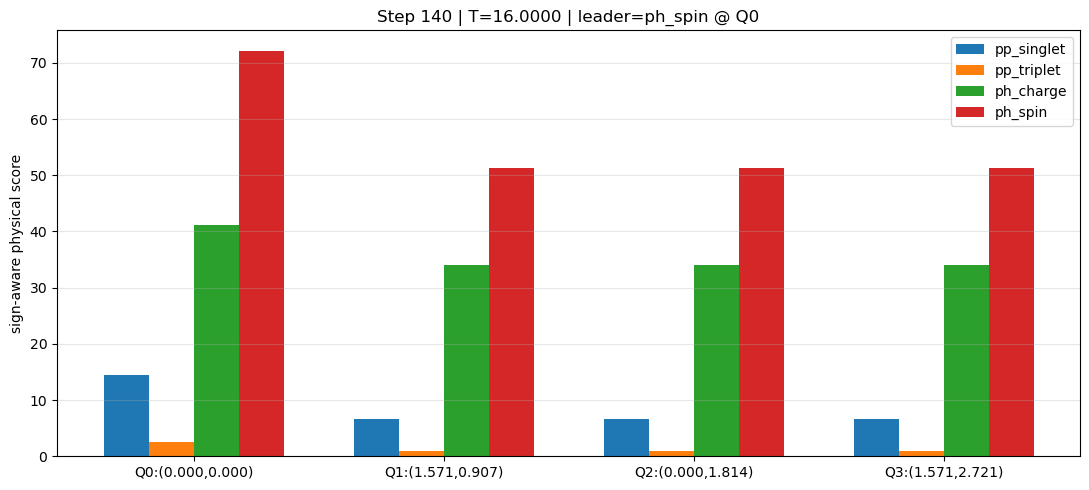

In [40]:
# ============================================================
# Cell 3
# 画 step 164 的四通道柱状图
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_signaware_bar_for_step(step_idx):
    df = signaware_df_at_step(step_idx)

    q_keys = sorted(df["Q_index"].unique().tolist())
    q_labels = []
    for iq in q_keys:
        row = df[df["Q_index"] == iq].iloc[0]
        q_labels.append(f"Q{iq}:({row['Qx']:.3f},{row['Qy']:.3f})")

    channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    x = np.arange(len(q_keys))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 5))
    for j, ch in enumerate(channels_order):
        vals = []
        for iq in q_keys:
            sub = df[(df["channel"] == ch) & (df["Q_index"] == iq)]
            vals.append(float(sub.iloc[0]["physical_score"]) if len(sub) else 0.0)
        ax.bar(x + (j - 1.5) * width, vals, width=width, label=ch)

    rec = solver.history[step_idx]
    sa = rec.diagnosis_payload["sign_aware"]

    ax.set_xticks(x)
    ax.set_xticklabels(q_labels)
    ax.set_ylabel("sign-aware physical score")
    ax.set_title(
        f"Step {step_idx} | T={rec.temperature:.4f} | "
        f"leader={sa['leading_channel']} @ Q{sa['leading_Q_index']}"
    )
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_signaware_bar_for_step(140)